# Smart City Traffic Forecasting
## Leakage-safe 1–24 hour forecasting: GBDT models vs PatchTST

**Default target:** citywide hourly `vehicle_count`, summed over all 100 intersections. Change `TARGET` to `"average_speed"` to forecast mean network speed instead.

**What this notebook does**

- Builds a single operational citywide hourly series from the 100-intersection panel.
- Uses four expanding-window backtests, each forecasting the next 24 hours.
- Compares two gradient-boosted decision-tree (GBDT) implementations, 24-hour and 168-hour seasonal naïve baselines, and the PatchTST transformer.
- Evaluates MAE, RMSE, sMAPE, WAPE, and seasonally scaled error by model and horizon.
- Refits the methods on all available data and produces a genuine next-24-hour forecast.

**Design principle:** forecast-time features are limited to lagged target values and calendar variables known in advance. Observed future weather, incidents, congestion, and speed are not used; that would leak the future.

## 0. Why PatchTST?

PatchTST is a modern transformer architecture that treats subsequences (“patches”) as tokens, reducing attention cost while learning long temporal patterns. It was presented at ICLR 2023 and remains a strong, reproducible transformer baseline rather than a claim that one model is universally best.

Primary references:

- Nie et al., *A Time Series is Worth 64 Words: Long-term Forecasting with Transformers*: https://arxiv.org/abs/2211.14730
- Official NeuralForecast PatchTST documentation: https://nixtlaverse.nixtla.io/neuralforecast/models.patchtst.html
- NeuralForecast model capability overview: https://nixtlaverse.nixtla.io/neuralforecast/docs/capabilities/overview.html

Installation (run once if needed):

```python
%pip install pandas numpy matplotlib seaborn scikit-learn skforecast torch neuralforecast
```

In [1]:
import os
from pathlib import Path
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / ".cache"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
import sklearn
import skforecast
import torch

from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MAE

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sea.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})

print({
    "python_target": "3.10+", "sklearn": sklearn.__version__, "skforecast": skforecast.__version__,
    "torch": torch.__version__, "accelerator": "MPS" if torch.backends.mps.is_available() else "CPU"
})

2026-09-02 12:47:24,280	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-09-02 12:47:24,729	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


{'python_target': '3.10+', 'sklearn': '1.9.0', 'skforecast': '0.24.0', 'torch': '2.14.0', 'accelerator': 'CPU'}


## 1. Configuration and target construction

`vehicle_count` is additive across intersections, so citywide aggregation uses a sum. `average_speed` is not additive, so its citywide aggregation uses a mean. The horizon, backtest windows, and lag set are visible here rather than hidden inside a pipeline.

In [2]:
TARGET = "vehicle_count"       # Alternative: "average_speed"
HORIZON = 24                   # Forecast steps: 1 through 24 hours ahead
N_SPLITS = 4                   # Four non-overlapping, rolling 24-hour test windows
MAX_PATCHTST_STEPS = 200       # Still compact; raise further only through validation-led tuning
INPUT_SIZE = 336               # Two weeks of hourly context for PatchTST
LAGS = list(range(1, 25)) + [48, 72, 168, 336]
AGGREGATION = {"vehicle_count": "sum", "average_speed": "mean"}

DATA_CANDIDATES = [
    Path("work/smart_city_traffic_mobility.csv"),
    Path("/Users/khoatran3126/Downloads/smart_city_traffic_mobility.csv"),
    Path("smart_city_traffic_mobility.csv"), Path("../smart_city_traffic_mobility.csv"),
    Path("/content/smart_city_traffic_mobility.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Update DATA_CANDIDATES so one entry points to smart_city_traffic_mobility.csv")
if TARGET not in AGGREGATION:
    raise ValueError(f"TARGET must be one of {list(AGGREGATION)}")

raw = pd.read_csv(DATA_PATH, usecols=["timestamp", "intersection_id", TARGET], parse_dates=["timestamp"])
aggregate = AGGREGATION[TARGET]
series = (raw.groupby("timestamp", as_index=False)
             .agg(y=(TARGET, aggregate))
             .rename(columns={"timestamp": "ds"})
             .sort_values("ds")
             .reset_index(drop=True))
series["unique_id"] = f"citywide_{TARGET}"
print(f"Target: {TARGET} ({aggregate} across intersections)")
print(f"Coverage: {series.ds.min()} to {series.ds.max()} | {len(series):,} hourly points")
display(series.head())

Target: vehicle_count (sum across intersections)
Coverage: 2026-01-01 00:00:00 to 2026-03-26 23:00:00 | 2,040 hourly points


,ds,y,unique_id
0,2026-01-01 00:00:00,19370,citywide_vehicle_count
1,2026-01-01 01:00:00,19155,citywide_vehicle_count
2,2026-01-01 02:00:00,18974,citywide_vehicle_count
3,2026-01-01 03:00:00,18730,citywide_vehicle_count
4,2026-01-01 04:00:00,19014,citywide_vehicle_count


In [3]:
# Integrity checks run before any model sees the data.
expected = pd.date_range(series.ds.min(), series.ds.max(), freq="h")
checks = pd.Series({
    "hourly_clock_complete": pd.DatetimeIndex(series.ds).equals(expected),
    "timestamp_unique": series.ds.is_unique,
    "target_non_missing": series.y.notna().all(),
    "target_finite": np.isfinite(series.y).all(),
    "target_nonnegative": series.y.ge(0).all(),
    "enough_history_for_lags_and_splits": len(series) > max(LAGS) + N_SPLITS * HORIZON,
}, name="passed")
display(checks.to_frame())
assert checks.all(), "Fix failed integrity checks before modeling."

,passed
hourly_clock_complete,True
timestamp_unique,True
target_non_missing,True
target_finite,True
target_nonnegative,True
enough_history_for_lags_and_splits,True


## 2. Understand the series before forecasting

The plots below expose scale, daily rhythm, weekly differences, and autocorrelation. A strong 168-hour repeat pattern justifies the “same hour last week” baseline and lag.

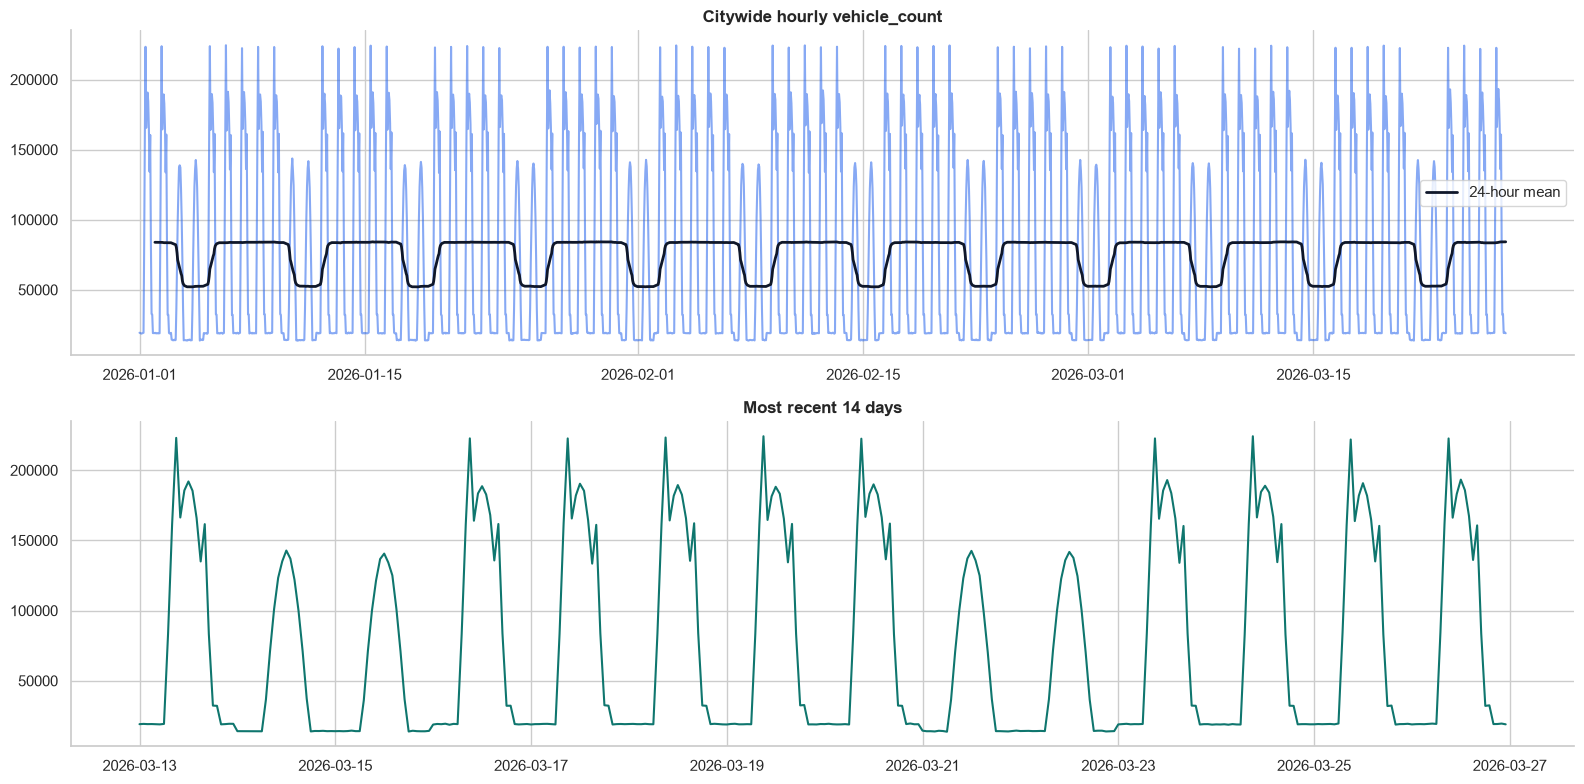

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(series.ds, series.y, color="#2563EB", alpha=.55)
axes[0].plot(series.ds, series.y.rolling(24).mean(), color="#0F172A", linewidth=2, label="24-hour mean")
axes[0].set_title(f"Citywide hourly {TARGET}"); axes[0].legend()
recent = series.tail(24 * 14)
axes[1].plot(recent.ds, recent.y, color="#0F766E")
axes[1].set_title("Most recent 14 days")
plt.tight_layout(); plt.show()

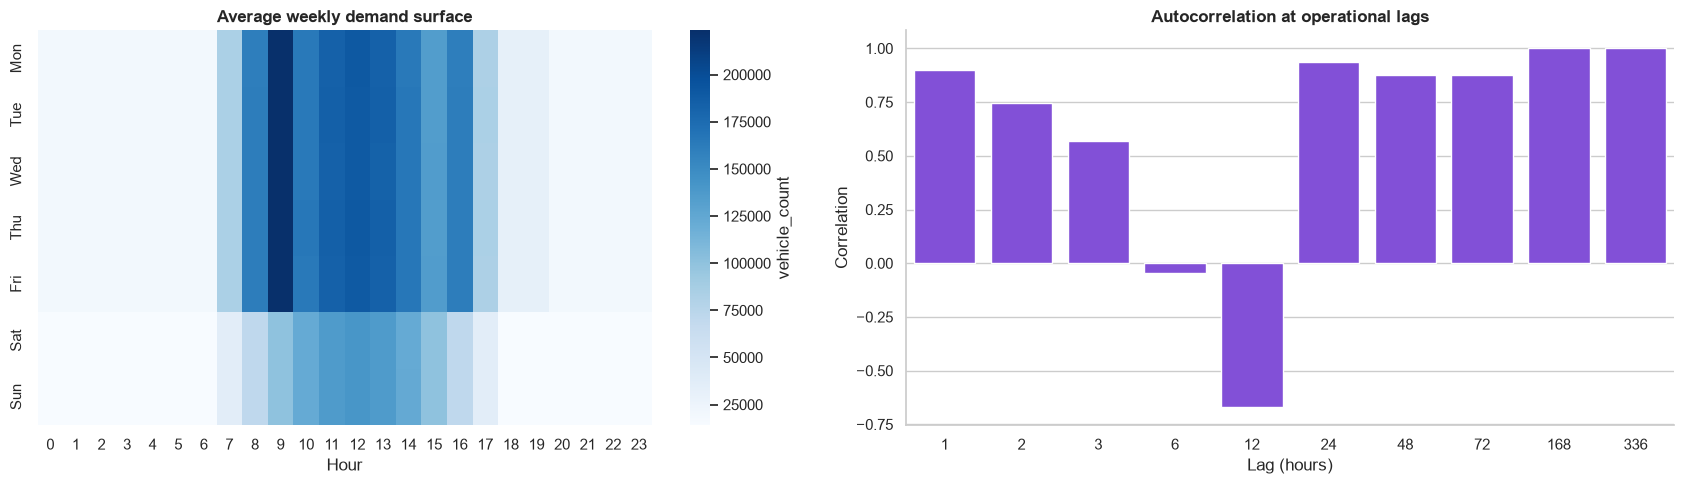

,lag_hours,autocorrelation
0,1,0.902
1,2,0.745
2,3,0.570
3,6,-0.045
4,12,-0.671
5,24,0.939
6,48,0.876
7,72,0.877
8,168,1.000
9,336,1.000


In [5]:
profile = series.assign(hour=series.ds.dt.hour, day_of_week=series.ds.dt.dayofweek)
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly = profile.groupby(["day_of_week", "hour"]).y.mean().unstack()
weekly.index = day_names

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sea.heatmap(weekly, cmap="Blues", ax=axes[0], cbar_kws={"label": TARGET})
axes[0].set_title("Average weekly demand surface"); axes[0].set_xlabel("Hour"); axes[0].set_ylabel("")
ac_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
ac_values = [series.y.autocorr(lag=lag) for lag in ac_lags]
sea.barplot(x=ac_lags, y=ac_values, ax=axes[1], color="#7C3AED")
axes[1].set_title("Autocorrelation at operational lags"); axes[1].set_xlabel("Lag (hours)"); axes[1].set_ylabel("Correlation")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"lag_hours": ac_lags, "autocorrelation": ac_values}))

## 3. Backtest design: expanding training windows

`TimeSeriesSplit` creates four chronological test windows. Every test window is exactly 24 hours, and each model is trained only on observations strictly before that window. The windows do not overlap, which makes the 96 forecast errors easy to interpret.

In [6]:
splitter = TimeSeriesSplit(n_splits=N_SPLITS, test_size=HORIZON)
folds = []
split_indices = list(splitter.split(series))
for fold, (train_idx, test_idx) in enumerate(split_indices, start=1):
    folds.append({
        "fold": fold, "train_start": series.ds.iloc[train_idx[0]], "train_end": series.ds.iloc[train_idx[-1]],
        "train_rows": len(train_idx), "test_start": series.ds.iloc[test_idx[0]],
        "test_end": series.ds.iloc[test_idx[-1]], "test_rows": len(test_idx),
    })
fold_table = pd.DataFrame(folds)
display(fold_table)

,fold,train_start,train_end,train_rows,test_start,test_end,test_rows
0,1,2026-01-01,2026-03-22 23:00:00,1944,2026-03-23,2026-03-23 23:00:00,24
1,2,2026-01-01,2026-03-23 23:00:00,1968,2026-03-24,2026-03-24 23:00:00,24
2,3,2026-01-01,2026-03-24 23:00:00,1992,2026-03-25,2026-03-25 23:00:00,24
3,4,2026-01-01,2026-03-25 23:00:00,2016,2026-03-26,2026-03-26 23:00:00,24


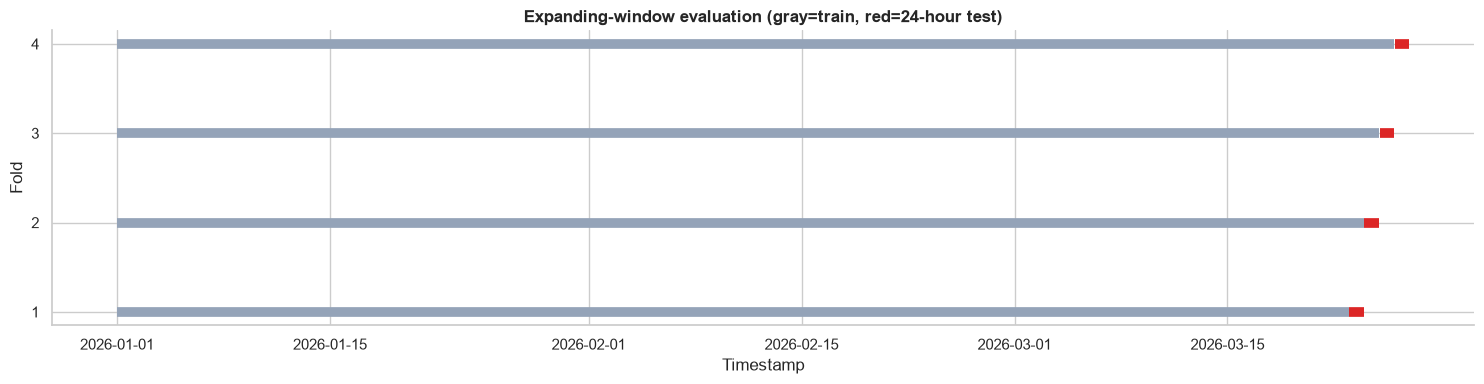

In [7]:
plt.figure(figsize=(15, 4))
for row in fold_table.itertuples():
    plt.plot([row.train_start, row.train_end], [row.fold, row.fold], linewidth=7, color="#94A3B8", solid_capstyle="butt")
    plt.plot([row.test_start, row.test_end], [row.fold, row.fold], linewidth=7, color="#DC2626", solid_capstyle="butt")
plt.yticks(fold_table.fold)
plt.xlabel("Timestamp"); plt.ylabel("Fold")
plt.title("Expanding-window evaluation (gray=train, red=24-hour test)")
plt.tight_layout(); plt.show()

## 4. Transparent multi-horizon feature construction

For forecast origin time `t`, `lag_1` is the most recently observed value (`t−1`) and `lag_168` is the same hour one week earlier. Calendar sine/cosine terms describe the **forecasted timestamp** at each horizon and are known in advance.

A separate direct model is fitted for each horizon. Direct forecasting avoids feeding uncertain 1-step predictions back into later horizons.

In [8]:
def calendar_features(timestamp):
    '''Calendar fields known before the forecasted hour occurs.'''
    hour = timestamp.hour
    dow = timestamp.dayofweek
    return {
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7),
        "dow_cos": np.cos(2 * np.pi * dow / 7),
        "is_weekend": int(dow >= 5),
    }

def feature_row(values, dates, origin, horizon, lags=LAGS):
    '''Create features available at origin for the specified future horizon.'''
    row = {f"lag_{lag}": values[origin - lag] for lag in lags}
    forecast_time = dates.iloc[origin + horizon - 1]
    row.update(calendar_features(forecast_time))
    row["horizon"] = horizon
    return row

def training_frame(values, dates, train_end, horizon, lags=LAGS):
    '''Use only targets strictly before train_end; train_end is the forecast origin.'''
    first_origin = max(lags)
    last_origin = train_end - horizon
    origins = range(first_origin, last_origin + 1)
    X = pd.DataFrame([feature_row(values, dates, t, horizon, lags) for t in origins])
    y = np.array([values[t + horizon - 1] for t in origins])
    return X, y

demo_X, demo_y = training_frame(series.y.to_numpy(), series.ds, split_indices[0][1][0], horizon=1)
print(f"Example training matrix: {demo_X.shape}")
display(demo_X.head(3), pd.Series(demo_y[:3], name="target"))

Example training matrix: (1608, 34)


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_48,lag_72,lag_168,lag_336,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,horizon
0,19235,18984,18920,19298,32310,32023,83914,161588,134259,168107,...,18891,19300,18837,19370,0.000,1.000,0.434,-0.901,0,1
1,18861,19235,18984,18920,19298,32310,32023,83914,161588,134259,...,19073,19364,19298,19155,0.259,0.966,0.434,-0.901,0,1
2,19152,18861,19235,18984,18920,19298,32310,32023,83914,161588,...,18994,19172,18942,18974,0.500,0.866,0.434,-0.901,0,1


0    18861
1    19152
2    19079
Name: target, dtype: int64

## 5. Baselines and GBDT models

Two GBDT variants provide different regularization/optimization behavior while remaining easy to run on CPU:

- `HistGradientBoostingRegressor`: histogram-binned boosting; efficient and strongly regularized.
- `GradientBoostingRegressor` with Huber loss: classic boosting with reduced sensitivity to large errors.

The seasonal naïve baselines are essential. A complex model is not useful if it cannot beat the same hour yesterday or last week.

In [9]:
def new_gbdt_models():
    return {
        "HistGBDT": HistGradientBoostingRegressor(
            loss="squared_error", learning_rate=0.06, max_iter=180,
            max_leaf_nodes=31, min_samples_leaf=20, l2_regularization=0.2,
            random_state=RANDOM_SEED,
        ),
        "HuberGBDT": GradientBoostingRegressor(
            loss="huber", learning_rate=0.04, n_estimators=160,
            max_depth=3, min_samples_leaf=12, subsample=0.9,
            random_state=RANDOM_SEED,
        ),
    }

values = series.y.to_numpy(dtype=float)
dates = series.ds
prediction_rows = []
fit_times = []

for fold, (_, test_idx) in enumerate(split_indices, start=1):
    origin = int(test_idx[0])
    fold_start = time.perf_counter()

    # Simple baselines use information available at the forecast origin.
    for h in range(1, HORIZON + 1):
        target_idx = origin + h - 1
        actual = values[target_idx]
        common = {"fold": fold, "origin": dates.iloc[origin], "ds": dates.iloc[target_idx], "horizon": h, "actual": actual}
        prediction_rows.append({**common, "model": "Naive_24h", "prediction": values[target_idx - 24]})
        prediction_rows.append({**common, "model": "Naive_168h", "prediction": values[target_idx - 168]})

    # Fit one direct model per horizon. No test-window target appears in training.
    for model_name in ["HistGBDT", "HuberGBDT"]:
        for h in range(1, HORIZON + 1):
            model = new_gbdt_models()[model_name]
            X_train, y_train = training_frame(values, dates, origin, h)
            X_test = pd.DataFrame([feature_row(values, dates, origin, h)])
            model.fit(X_train, y_train)
            pred = float(model.predict(X_test)[0])
            target_idx = origin + h - 1
            prediction_rows.append({
                "fold": fold, "origin": dates.iloc[origin], "ds": dates.iloc[target_idx], "horizon": h,
                "actual": values[target_idx], "model": model_name, "prediction": max(0.0, pred),
            })
    fit_times.append({"fold": fold, "family": "baselines + GBDT", "seconds": time.perf_counter() - fold_start})

gbdt_predictions = pd.DataFrame(prediction_rows)
print(f"Created {len(gbdt_predictions):,} baseline/GBDT predictions.")
display(pd.DataFrame(fit_times))

Created 384 baseline/GBDT predictions.


,fold,family,seconds
0,1,baselines + GBDT,26.034
1,2,baselines + GBDT,26.841
2,3,baselines + GBDT,26.483
3,4,baselines + GBDT,26.966


## 6. PatchTST under the same fold cutoffs

PatchTST produces all 24 horizons directly from the previous 336 hours. For notebook runtime, training is capped at `MAX_PATCHTST_STEPS=200`; a production experiment should tune this using validation loss and multiple random seeds.

Scaling is learned inside each training fold. The test window is never passed to `.fit()`.

In [10]:
transformer_rows = []
transformer_times = []

for fold, (_, test_idx) in enumerate(split_indices, start=1):
    origin = int(test_idx[0])
    train_nf = series.iloc[:origin][["unique_id", "ds", "y"]].copy()

    patch_model = PatchTST(
        h=HORIZON, input_size=INPUT_SIZE, encoder_layers=2, n_heads=4,
        hidden_size=32, linear_hidden_size=64, patch_len=24, stride=12,
        dropout=0.1, fc_dropout=0.1, head_dropout=0.0,
        scaler_type="robust", loss=MAE(), learning_rate=1e-3,
        max_steps=MAX_PATCHTST_STEPS, batch_size=32, windows_batch_size=64,
        random_seed=RANDOM_SEED, enable_progress_bar=False, logger=False,
    )
    nf = NeuralForecast(models=[patch_model], freq="h")
    started = time.perf_counter()
    nf.fit(df=train_nf, val_size=48)
    pred = nf.predict().reset_index()
    transformer_times.append({"fold": fold, "family": "PatchTST", "seconds": time.perf_counter() - started})

    pred_values = pred["PatchTST"].to_numpy()[:HORIZON]
    for h, value in enumerate(pred_values, start=1):
        target_idx = origin + h - 1
        transformer_rows.append({
            "fold": fold, "origin": dates.iloc[origin], "ds": dates.iloc[target_idx], "horizon": h,
            "actual": values[target_idx], "model": "PatchTST", "prediction": max(0.0, float(value)),
        })

transformer_predictions = pd.DataFrame(transformer_rows)
predictions = pd.concat([gbdt_predictions, transformer_predictions], ignore_index=True)
display(pd.DataFrame(fit_times + transformer_times))
print(f"Total comparable predictions: {len(predictions):,}")

Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 40.3 K | train
------------------------------------------------------------------
40.3 K    Trainable params
2         Non-trainable params
40.3 K    Total params
0.161     Total estimated model params size (MB)
68        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


...

`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


,fold,family,seconds
0,1,baselines + GBDT,26.034
1,2,baselines + GBDT,26.841
2,3,baselines + GBDT,26.483
3,4,baselines + GBDT,26.966
4,1,PatchTST,1.935
5,2,PatchTST,1.809
6,3,PatchTST,1.817
7,4,PatchTST,1.847


Total comparable predictions: 480


## 7. Comparable metrics

- **MAE:** typical absolute error in target units.
- **RMSE:** penalizes large misses more heavily.
- **sMAPE:** scale-free percentage error, with a stable denominator.
- **WAPE:** total absolute error divided by total actual volume.
- **MASE-24:** absolute error scaled by in-sample 24-hour seasonal-naïve error; values below 1 beat the training seasonal baseline on average.

In [11]:
# Compute a fold-specific seasonal scale from training only.
fold_scales = {}
for fold, (_, test_idx) in enumerate(split_indices, start=1):
    origin = int(test_idx[0])
    train_y = values[:origin]
    fold_scales[fold] = np.mean(np.abs(train_y[24:] - train_y[:-24]))
predictions["abs_error"] = (predictions.actual - predictions.prediction).abs()
predictions["sq_error"] = (predictions.actual - predictions.prediction) ** 2
predictions["smape_component"] = 200 * predictions.abs_error / (predictions.actual.abs() + predictions.prediction.abs() + 1e-9)
predictions["mase_component"] = predictions.apply(lambda r: r.abs_error / fold_scales[r.fold], axis=1)

def metric_table(frame, group="model"):
    return (frame.groupby(group)
            .agg(MAE=("abs_error", "mean"), RMSE=("sq_error", lambda s: np.sqrt(s.mean())),
                 sMAPE_pct=("smape_component", "mean"), WAPE_pct=("abs_error", lambda s: 100 * s.sum() / frame.loc[s.index, "actual"].abs().sum()),
                 MASE_24=("mase_component", "mean"), n=("actual", "size"))
            .sort_values("MAE"))

overall_metrics = metric_table(predictions)
display(overall_metrics.style.background_gradient(subset=["MAE", "RMSE", "sMAPE_pct", "WAPE_pct", "MASE_24"], cmap="YlGn_r").format("{:.3f}"))

,MAE,RMSE,sMAPE_pct,WAPE_pct,MASE_24,n
model,,,,,,
Naive_168h,704.000,1126.181,0.937,0.840,0.074,96.000
HistGBDT,747.866,1499.372,1.009,0.892,0.078,96.000
HuberGBDT,1967.697,6269.278,1.812,2.346,0.207,96.000
Naive_24h,8370.208,22416.754,11.510,9.981,0.884,96.000
PatchTST,9012.555,14730.182,17.503,10.747,0.944,96.000


model,HistGBDT,HuberGBDT,Naive_168h,Naive_24h,PatchTST
fold,,,,,
1,"1,081.304","4,515.829",746.917,"31,206.042","15,428.685"
2,298.753,"1,228.645",632.375,608.458,"7,093.519"
3,759.051,701.324,523.125,866.000,"6,698.503"
4,852.356,"1,424.991",913.583,800.333,"6,829.513"


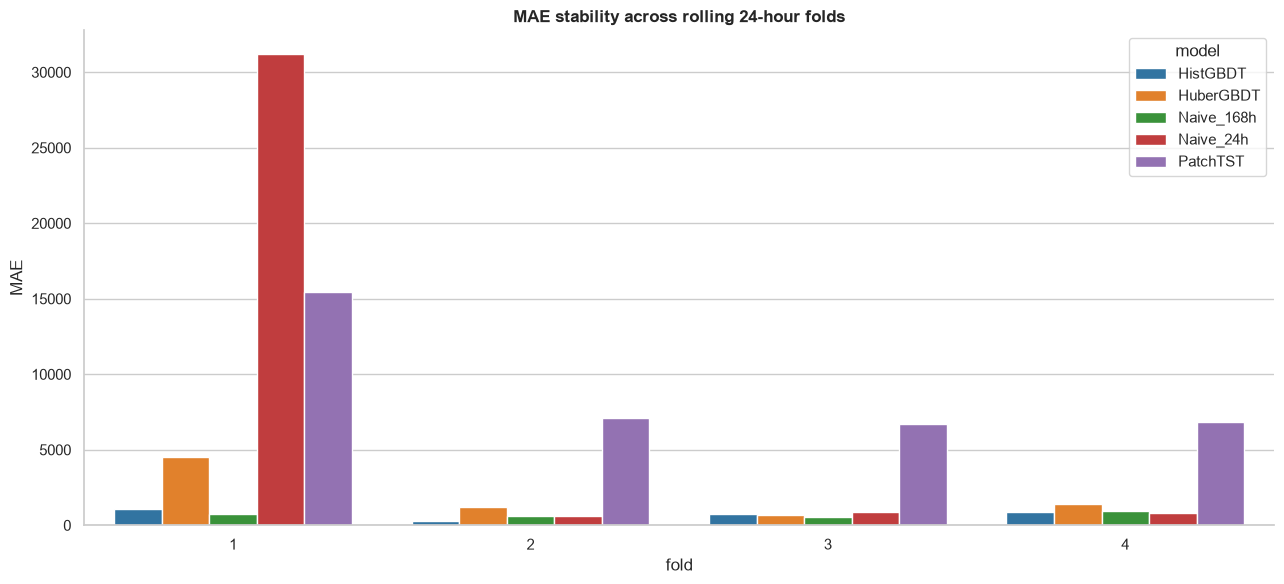

In [12]:
fold_metrics = (predictions.groupby(["fold", "model"])
                .agg(MAE=("abs_error", "mean"), RMSE=("sq_error", lambda s: np.sqrt(s.mean())),
                     sMAPE_pct=("smape_component", "mean"), MASE_24=("mase_component", "mean"))
                .reset_index())
display(fold_metrics.pivot(index="fold", columns="model", values="MAE"))

plt.figure(figsize=(13, 6))
sea.barplot(data=fold_metrics, x="fold", y="MAE", hue="model", palette="tab10")
plt.title("MAE stability across rolling 24-hour folds")
plt.tight_layout(); plt.show()

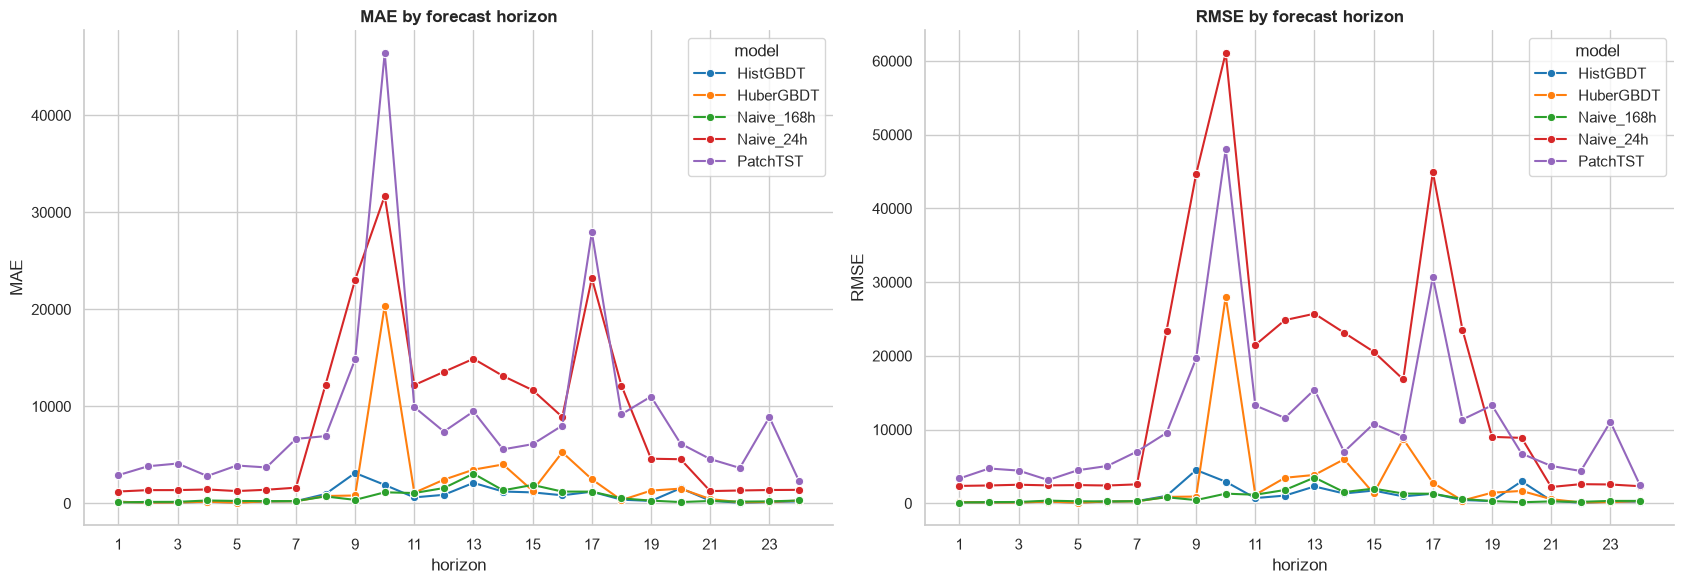

In [13]:
horizon_metrics = (predictions.groupby(["horizon", "model"])
                   .agg(MAE=("abs_error", "mean"), RMSE=("sq_error", lambda s: np.sqrt(s.mean())))
                   .reset_index())
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sea.lineplot(data=horizon_metrics, x="horizon", y="MAE", hue="model", marker="o", ax=axes[0], palette="tab10")
sea.lineplot(data=horizon_metrics, x="horizon", y="RMSE", hue="model", marker="o", ax=axes[1], palette="tab10")
axes[0].set_title("MAE by forecast horizon"); axes[1].set_title("RMSE by forecast horizon")
for ax in axes: ax.set_xticks(range(1, 25, 2))
plt.tight_layout(); plt.show()

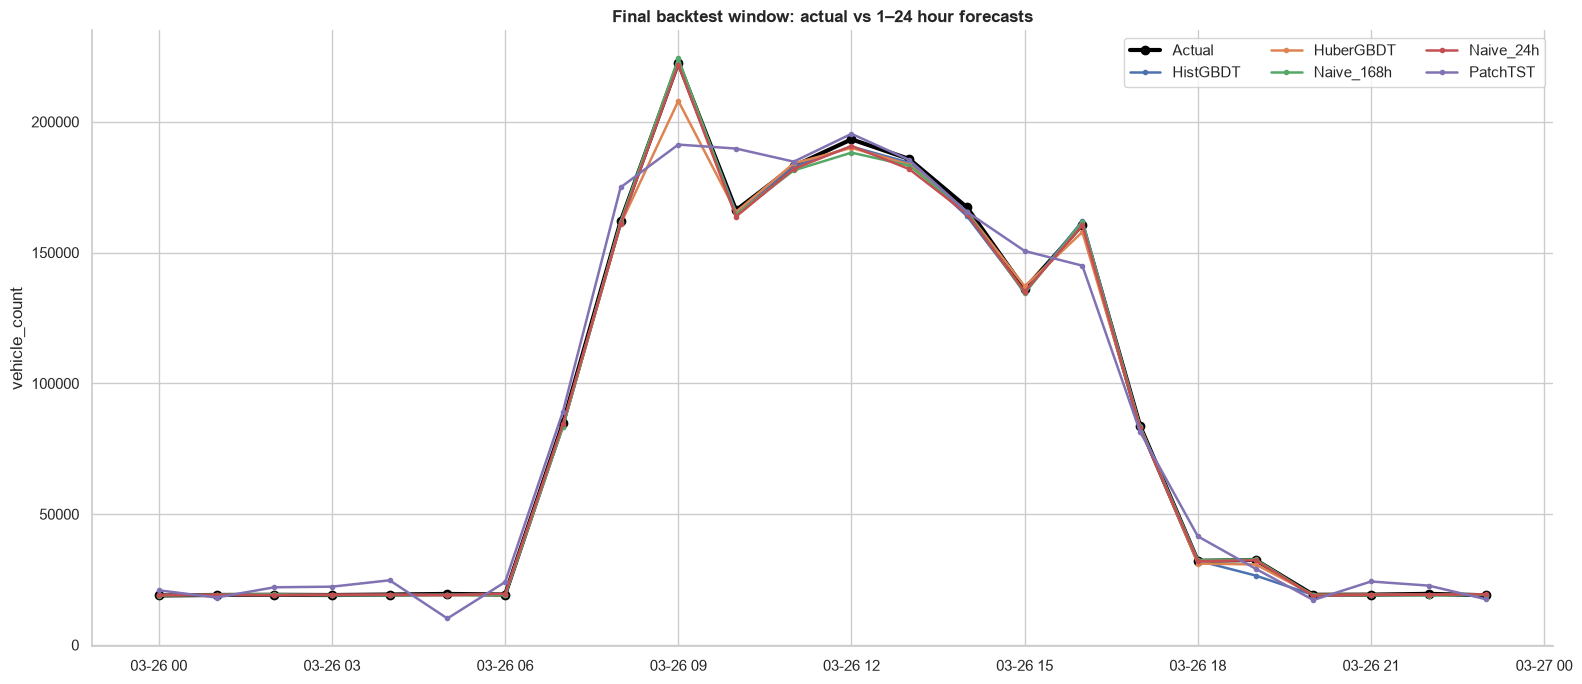

In [14]:
final_fold = predictions[predictions.fold.eq(N_SPLITS)].copy()
plt.figure(figsize=(16, 7))
actual_line = final_fold.drop_duplicates("ds").sort_values("ds")
plt.plot(actual_line.ds, actual_line.actual, color="black", linewidth=3, marker="o", label="Actual")
for model_name, group in final_fold.groupby("model"):
    group = group.sort_values("ds")
    plt.plot(group.ds, group.prediction, linewidth=1.8, marker=".", label=model_name)
plt.title("Final backtest window: actual vs 1–24 hour forecasts")
plt.ylabel(TARGET); plt.legend(ncol=3)
plt.tight_layout(); plt.show()

## 8. What the GBDT models use

Feature importance is inspected at 1-hour and 24-hour horizons using the final training fold. Importance is model-specific and does not imply causality; it shows which available lags/calendar fields the fitted tree relied upon.

,horizon,feature,importance
26,1,lag_168,0.632
27,1,lag_336,0.367
32,1,is_weekend,0.000
29,1,hour_cos,0.000
24,1,lag_48,0.000
30,1,dow_sin,0.000
0,1,lag_1,0.000
25,1,lag_72,0.000
5,1,lag_6,0.000
7,1,lag_8,0.000


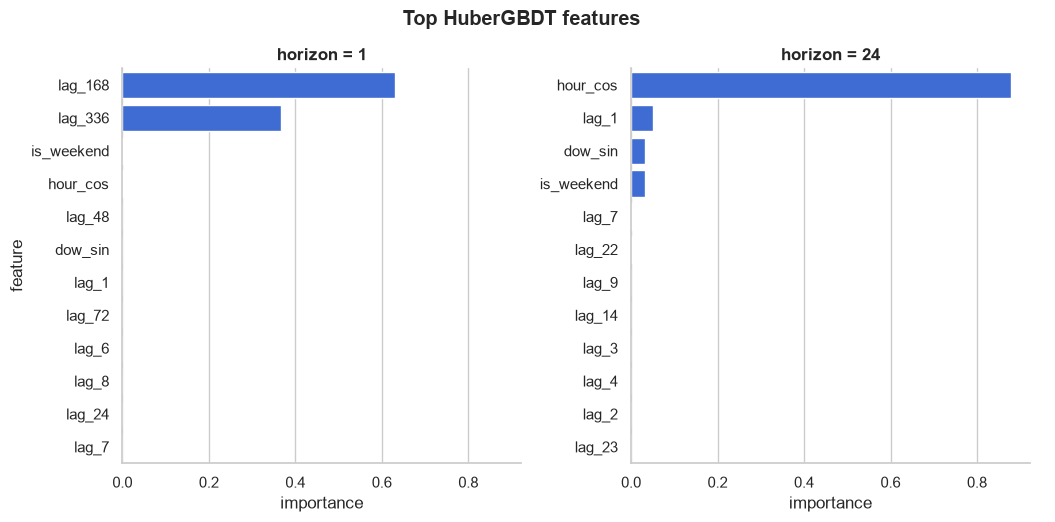

In [15]:
final_origin = int(split_indices[-1][1][0])
importance_rows = []
for h in [1, 24]:
    X_train, y_train = training_frame(values, dates, final_origin, h)
    model = new_gbdt_models()["HuberGBDT"]
    model.fit(X_train, y_train)
    importance_rows.extend({"horizon": h, "feature": f, "importance": imp}
                           for f, imp in zip(X_train.columns, model.feature_importances_))
importances = pd.DataFrame(importance_rows)
top_features = (importances.sort_values(["horizon", "importance"], ascending=[True, False])
                .groupby("horizon").head(12))
display(top_features)

sea.catplot(data=top_features, y="feature", x="importance", col="horizon", kind="bar", sharey=False, height=5, aspect=1.05, color="#2563EB")
plt.suptitle("Top HuberGBDT features", y=1.04, fontweight="bold")
plt.show()

## 9. Refit on all data and forecast the next 24 hours

The final table contains one forecast per model and a simple validation-weighted ensemble. Ensemble weights are inverse cross-validated MAE, so better backtest performers receive more influence without using future observations.

In [16]:
future_dates = pd.date_range(series.ds.iloc[-1] + pd.Timedelta(hours=1), periods=HORIZON, freq="h")
future_rows = []
full_origin = len(series)

# Seasonal baselines remain eligible for deployment; complexity must earn its place.
for h in range(1, HORIZON + 1):
    target_idx = full_origin + h - 1
    future_rows.append({"ds": future_dates[h-1], "horizon": h, "model": "Naive_24h",
                        "prediction": values[target_idx - 24]})
    future_rows.append({"ds": future_dates[h-1], "horizon": h, "model": "Naive_168h",
                        "prediction": values[target_idx - 168]})

# Direct GBDT forecasts fitted on every available observation.
for model_name in ["HistGBDT", "HuberGBDT"]:
    for h in range(1, HORIZON + 1):
        model = new_gbdt_models()[model_name]
        X_train, y_train = training_frame(values, dates, full_origin, h)
        # feature_row needs the future timestamp at origin+h-1; extend the date vector only.
        extended_dates = pd.concat([dates, pd.Series(future_dates)], ignore_index=True)
        X_future = pd.DataFrame([feature_row(values, extended_dates, full_origin, h)])
        model.fit(X_train, y_train)
        future_rows.append({"ds": future_dates[h-1], "horizon": h, "model": model_name,
                            "prediction": max(0.0, float(model.predict(X_future)[0]))})

# Final PatchTST fit on the full series.
final_patch = PatchTST(
    h=HORIZON, input_size=INPUT_SIZE, encoder_layers=2, n_heads=4,
    hidden_size=32, linear_hidden_size=64, patch_len=24, stride=12,
    dropout=0.1, fc_dropout=0.1, scaler_type="robust", loss=MAE(),
    learning_rate=1e-3, max_steps=MAX_PATCHTST_STEPS,
    batch_size=32, windows_batch_size=64, random_seed=RANDOM_SEED,
    enable_progress_bar=False, logger=False,
)
final_nf = NeuralForecast(models=[final_patch], freq="h")
final_nf.fit(df=series[["unique_id", "ds", "y"]], val_size=48)
patch_future = final_nf.predict().reset_index()
for h, pred in enumerate(patch_future.PatchTST.to_numpy()[:HORIZON], start=1):
    future_rows.append({"ds": future_dates[h-1], "horizon": h, "model": "PatchTST", "prediction": max(0.0, float(pred))})

future_long = pd.DataFrame(future_rows)
cv_models = overall_metrics.index.tolist()
inverse_mae = 1 / overall_metrics.loc[cv_models, "MAE"]
weights = inverse_mae / inverse_mae.sum()
print("Validation-derived ensemble weights:")
display(weights.rename("weight").to_frame())

future_wide = future_long.pivot(index=["ds", "horizon"], columns="model", values="prediction").reset_index()
future_wide["WeightedEnsemble"] = sum(future_wide[m] * weights[m] for m in cv_models)
best_cv_model = overall_metrics.index[0]
future_wide["RecommendedForecast"] = future_wide[best_cv_model]
print(f"Recommended single model from cross-validation: {best_cv_model}")
display(future_wide)

Seed set to 42


GPU available: False, used: False


TPU available: False, using: 0 TPU cores



  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 40.3 K | train
------------------------------------------------------------------
40.3 K    Trainable params
2         Non-trainable params
40.3 K    Total params
0.161     Total estimated model params size (MB)
68        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_steps=200` reached.


...

TPU available: False, using: 0 TPU cores


Validation-derived ensemble weights:


,weight
model,
Naive_168h,0.406
HistGBDT,0.382
HuberGBDT,0.145
Naive_24h,0.034
PatchTST,0.032


Recommended single model from cross-validation: Naive_168h


model,ds,horizon,HistGBDT,HuberGBDT,Naive_168h,Naive_24h,PatchTST,WeightedEnsemble,RecommendedForecast
0,2026-03-27 00:00:00,1,"19,092.740","19,118.419","19,141.000","18,923.000","39,506.355","19,758.126","19,141.000"
1,2026-03-27 01:00:00,2,"19,091.847","19,082.284","19,380.000","19,107.000","22,654.711","19,321.117","19,380.000"
2,2026-03-27 02:00:00,3,"19,094.965","19,133.053","19,043.000","19,167.000","15,823.668","18,978.033","19,043.000"
3,2026-03-27 03:00:00,4,"19,091.081","19,136.616","18,919.000","19,081.000","25,843.938","19,241.751","18,919.000"
4,2026-03-27 04:00:00,5,"19,082.225","19,127.076","18,956.000","19,265.000","31,223.029","19,429.008","18,956.000"
5,2026-03-27 05:00:00,6,"19,073.081","19,133.463","19,127.000","19,502.000","17,135.113","19,056.918","19,127.000"
6,2026-03-27 06:00:00,7,"19,125.688","19,131.706","18,875.000","19,264.000","28,138.359","19,315.465","18,875.000"
7,2026-03-27 07:00:00,8,"84,199.759","83,810.207","83,228.000","84,717.000","85,237.281","83,798.928","83,228.000"
8,2026-03-27 08:00:00,9,"161,350.415","162,277.979","160,619.000","161,890.000","144,374.984","160,667.790","160,619.000"
9,2026-03-27 09:00:00,10,"223,152.539","218,047.612","222,459.000","222,629.000","164,613.578","220,253.036","222,459.000"


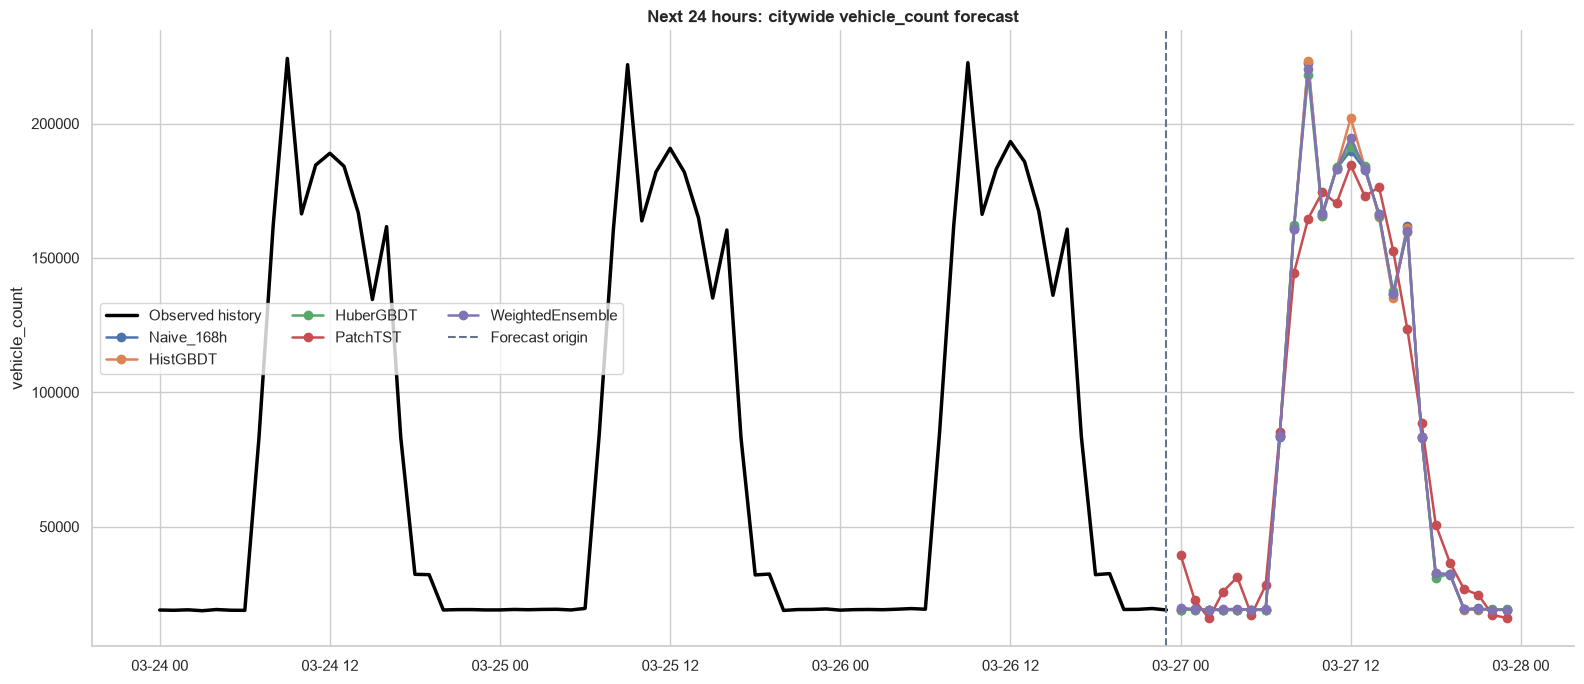

In [17]:
plt.figure(figsize=(16, 7))
history = series.tail(72)
plt.plot(history.ds, history.y, color="black", linewidth=2.5, label="Observed history")
for col in ["Naive_168h", "HistGBDT", "HuberGBDT", "PatchTST", "WeightedEnsemble"]:
    plt.plot(future_wide.ds, future_wide[col], marker="o", linewidth=1.8, label=col)
plt.axvline(series.ds.iloc[-1], color="#64748B", linestyle="--", label="Forecast origin")
plt.title(f"Next 24 hours: citywide {TARGET} forecast")
plt.ylabel(TARGET); plt.legend(ncol=3)
plt.tight_layout(); plt.show()

In [18]:
best_model = overall_metrics.index[0]
best_mae = overall_metrics.iloc[0].MAE
naive_week_mae = overall_metrics.loc["Naive_168h", "MAE"]
improvement = 100 * (naive_week_mae - best_mae) / naive_week_mae
best_mase = overall_metrics.iloc[0].MASE_24

display(Markdown(f'''
### Decision summary

- **Best backtest MAE:** `{best_model}` with MAE **{best_mae:,.2f}**.
- **Improvement versus same hour last week:** **{improvement:+.1f}%** by MAE.
- **Seasonal-scaled performance:** best MASE-24 is **{best_mase:.3f}** (below 1 means better than the in-sample daily seasonal naïve scale).
- **Operational forecast:** use the `{best_model}` column (also copied to `RecommendedForecast`) as the default because it won the predefined cross-validation comparison. Retain `WeightedEnsemble` and model spread as robustness/risk indicators.
- **Do not infer universal superiority:** four folds cover only four days. Expand the backtest across seasons, holidays, incidents, and sensor outages before deployment.
'''))


### Decision summary

- **Best backtest MAE:** `Naive_168h` with MAE **704.00**.
- **Improvement versus same hour last week:** **+0.0%** by MAE.
- **Seasonal-scaled performance:** best MASE-24 is **0.074** (below 1 means better than the in-sample daily seasonal naïve scale).
- **Operational forecast:** use the `Naive_168h` column (also copied to `RecommendedForecast`) as the default because it won the predefined cross-validation comparison. Retain `WeightedEnsemble` and model spread as robustness/risk indicators.
- **Do not infer universal superiority:** four folds cover only four days. Expand the backtest across seasons, holidays, incidents, and sensor outages before deployment.


## 10. Production-readiness checklist

1. Increase backtest coverage (for example, 8–12 weeks of daily origins) and report uncertainty around metric differences.
2. Tune GBDT and PatchTST only inside training/validation periods; never tune on the final test windows.
3. Add genuinely known future inputs such as scheduled events, planned roadworks, and weather forecasts—never realized future values.
4. Forecast intersection or zone panels if staffing/routing decisions are local; reconcile them so local forecasts sum to city totals.
5. Add prediction intervals or conformal calibration, then monitor empirical coverage.
6. Retrain on a schedule and monitor drift in lag importance, residuals, and performance by horizon/day type.
7. Validate daylight-saving-time, timezone, delayed sensors, duplicated messages, and missing-hour handling before live use.

**Modeling note.** The notebook imports `skforecast` and uses scikit-learn-compatible GBDT estimators, but keeps the direct multi-horizon loop explicit because it is easier to audit. The same feature builder can later be wrapped in `skforecast` once the team chooses a deployment API.